# Dataset analysis
The first cell automatically selects the repository root.

In [1]:
# Make imports work whether VS Code starts in the repository or notebooks folder.
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError(f"Cannot find the project root from {Path.cwd()}")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: c:\Users\jahav\OneDrive\janudrive\project\EV-Charging-RL-Optimizer


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.config import project_path

In [3]:
path=project_path('data/raw/Indian_EV_Stations_Simplified.csv')
df=pd.read_csv(path)
print('Shape:',df.shape)
print('Columns:',df.columns.tolist())
display(df.head())

Shape: (855, 9)
Columns: ['Station Name', 'City', 'State', 'Latitude', 'Longitude', 'Operator', 'Usage Type', 'Connector Type', 'Power (kW)']


,Station Name,City,State,Latitude,Longitude,Operator,Usage Type,Connector Type,Power (kW)
0,Tata.ev Luxon Motors - Tata Power,Edappally,Kerala,10.011485,76.311387,Tata Power,Public - Membership Required,CCS (Type 2),60.0
1,TML Sree Gokulam Motors - Tata Power,Edappally,Kerala,10.039155,76.315559,Tata Power,Public - Membership Required,CCS (Type 2),30.0
2,Tata.ev Gokulam Motors - Tata Power,Choornikkara,Kerala,10.081303,76.339462,Tata Power,Public - Membership Required,CCS (Type 2),60.0
3,Taj Cochin Internation Airport Hotel - Tata Power,Nedumbassery,Kerala,10.159995,76.390154,Tata Power,Public - Membership Required,CCS (Type 2),30.0
4,SAJ Earth Resort - Tata Power,Nedumbassery,Kerala,10.162224,76.384653,Tata Power,Public - Membership Required,CCS (Type 2),30.0


In [4]:
print('Missing values:\n',df.isna().sum())
print('Duplicate rows:',df.duplicated().sum())

Missing values:
 Station Name      0
City              0
State             1
Latitude          0
Longitude         0
Operator          0
Usage Type        0
Connector Type    0
Power (kW)        2
dtype: int64
Duplicate rows: 66


Valid coordinates: 855


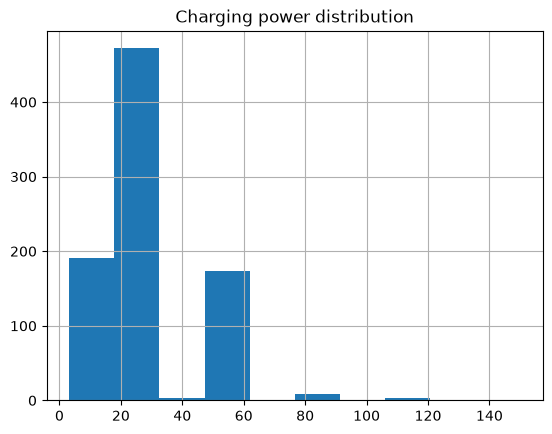

In [5]:
valid=df.Latitude.between(-90,90)&df.Longitude.between(-180,180)
print('Valid coordinates:',valid.sum())
df['Power (kW)'].hist(); plt.title('Charging power distribution'); plt.show()

In [6]:
display(df['Connector Type'].value_counts())
display(df.groupby('State').size().sort_values(ascending=False).head(15))

Connector Type
CCS (Type 2)                    565
CEE 3 Pin                       124
Type 2 (Tethered Connector)      91
CHAdeMO                          36
GB-T DC - GB/T 20234.3           34
Unknown                           3
IEC 60309 3-pin                   2
Name: count, dtype: int64

State
Kerala            769
Tamil Nadu         42
Keral              10
West Bengal         5
Karnataka           4
Maharashtra         4
Tamil Nadu          3
Keraka              3
Lerala              3
Andhra Pradesh      2
uttar pradesh       2
Delhi               1
Karnataka           1
Kerala              1
Madhya Pradesh      1
dtype: int64

In [7]:
print('Dataset Validation Summary\n--------------------------')
print('Rows:',len(df))
print('Valid coordinates:',valid.sum())
print('Duplicate stations:',df.duplicated(['Station Name','Latitude','Longitude']).sum())
print('Missing power:',df['Power (kW)'].isna().sum())
print('Connector types:',df['Connector Type'].nunique())
print('Power range:',df['Power (kW)'].min(),'-',df['Power (kW)'].max(),'kW')

Dataset Validation Summary
--------------------------
Rows: 855
Valid coordinates: 855
Duplicate stations: 355
Missing power: 2
Connector types: 7
Power range: 3.2 - 150.0 kW
